# Compare Simulation Excel Results

在下面的配置单元中填写 Excel/CSV 路径和要对比的变量名。Notebook 会自动读取多个结果文件，并画出变量随时间的对比曲线、相对 base case 的差值曲线和误差统计表。

In [6]:
from pathlib import Path

# ===== User configuration =====
# One well_time_data.xlsx file per case.
RESULTS_ROOT = Path(r"E:\Pure_CO2_S\mass_rate, 83c, 690well_dis")

CASE_DEFINITIONS = [
    {
        "case": "D-01",
        "label": "D-01 Baseline",
        "depth_m": 2000,
        "scenario": "Baseline",
        "horizontal_permeability_md": 800,
        "vertical_anisotropy": 0.1,
        "injection_rate": 50,
        "medium": "Homogeneous",
    },
    {
        "case": "D-02",
        "label": "D-02 Heterogeneity R60",
        "depth_m": 2000,
        "scenario": "Heterogeneity",
        "horizontal_permeability_md": "realization-specific",
        "vertical_anisotropy": 0.1,
        "injection_rate": 50,
        "medium": "Realization 60",
    },
    {
        "case": "D-03",
        "label": "D-03 Heterogeneity R43",
        "depth_m": 2000,
        "scenario": "Heterogeneity",
        "horizontal_permeability_md": "realization-specific",
        "vertical_anisotropy": 0.1,
        "injection_rate": 50,
        "medium": "Realization 43",
    },
    {
        "case": "D-04",
        "label": "D-04 Heterogeneity R8",
        "depth_m": 2000,
        "scenario": "Heterogeneity",
        "horizontal_permeability_md": "realization-specific",
        "vertical_anisotropy": 0.1,
        "injection_rate": 50,
        "medium": "Realization 8",
    },
    {
        "case": "D-05",
        "label": "D-05 Injection low",
        "depth_m": 2000,
        "scenario": "Injection rate: low",
        "horizontal_permeability_md": 800,
        "vertical_anisotropy": 0.1,
        "injection_rate": 25,
        "medium": "Homogeneous",
    },
    {
        "case": "D-06",
        "label": "D-06 Injection high",
        "depth_m": 2000,
        "scenario": "Injection rate: high",
        "horizontal_permeability_md": 800,
        "vertical_anisotropy": 0.1,
        "injection_rate": 100,
        "medium": "Homogeneous",
    },
    {
        "case": "D-07",
        "label": "D-07 Kh low",
        "depth_m": 2000,
        "scenario": "Horizontal permeability: low",
        "horizontal_permeability_md": 200,
        "vertical_anisotropy": 0.1,
        "injection_rate": 50,
        "medium": "Homogeneous",
    },
    {
        "case": "D-08",
        "label": "D-08 Kh medium-low",
        "depth_m": 2000,
        "scenario": "Horizontal permeability: medium-low",
        "horizontal_permeability_md": 400,
        "vertical_anisotropy": 0.1,
        "injection_rate": 50,
        "medium": "Homogeneous",
    },
    {
        "case": "D-09",
        "label": "D-09 Kh high",
        "depth_m": 2000,
        "scenario": "Horizontal permeability: high",
        "horizontal_permeability_md": 1600,
        "vertical_anisotropy": 0.1,
        "injection_rate": 50,
        "medium": "Homogeneous",
    },
    {
        "case": "D-10",
        "label": "D-10 Strong anisotropy",
        "depth_m": 2000,
        "scenario": "Strong vertical anisotropy",
        "horizontal_permeability_md": 800,
        "vertical_anisotropy": 0.01,
        "injection_rate": 50,
        "medium": "Homogeneous",
    },
    {
        "case": "D-11",
        "label": "D-11 Isotropic permeability",
        "depth_m": 2000,
        "scenario": "Isotropic permeability",
        "horizontal_permeability_md": 800,
        "vertical_anisotropy": 1,
        "injection_rate": 50,
        "medium": "Homogeneous",
    },
]

EXCEL_SPECS = [
    {
        "label": case["label"],
        "path": RESULTS_ROOT / case["case"] / "well_time_data.xlsx",
        "sheet_name": 0,
        **case,
    }
    for case in CASE_DEFINITIONS
]

# Variable column names to compare. They must match the Excel/CSV columns.
# Run the Inspect columns cell first if you need to see available names.
VARIABLES = [
    "well_I1_BHP",
    "well_P1_BHP",
    "well_I1_BHT",
    "well_P1_BHT",
    "well_P1_mass_rate_LCO2_at_wh",
    "well_I1_mass_rate_LCO2_at_wh",
    # "well_P1_advective_heat_rate_LCO2_by_sum_perfs",
    "heat_extraction_rate_MW",
]

# Heat extraction rate = Q * (h_produced - h_injected).
# Q uses producer mass rate; h uses CO2 enthalpy at the corresponding well BHP/BHT.
ADD_HEAT_EXTRACTION_RATE = True
HEAT_EXTRACTION_COLUMN = "heat_extraction_rate_MW"
HEAT_EXTRACTION_FLUID = "CO2"
PRODUCER_MASS_RATE_COLUMN = "well_P1_mass_rate_LCO2_at_wh"
PRODUCER_PRESSURE_COLUMN = "well_P1_BHP"
PRODUCER_TEMPERATURE_COLUMN = "well_P1_BHT"
INJECTOR_PRESSURE_COLUMN = "well_I1_BHP"
INJECTOR_TEMPERATURE_COLUMN = "well_I1_BHT"

# Time column name. Set to None to auto-detect common names such as time/Time/day/year.
TIME_COLUMN = None

# Initial rows to skip for every case. This can be an integer or a dict keyed by label.
SKIP_INITIAL_TIME_STEPS = 20

# Baseline case label for differences and error statistics.
BASE_LABEL = "D-01 Baseline"

# Time unit conversion. DARTS time is usually days; use 365 or 365.25 for years.
TIME_SCALE = 365
TIME_LABEL = "time, years"

# Figure output directory. Set to None to avoid saving figures.
OUTPUT_DIR = None

# Alignment method. Linear interpolation is suitable when cases use different time steps.
INTERPOLATION_METHOD = "linear"

# Plot appearance and rate handling.
SMOOTH_PLOT_POINTS = 600
ABS_RATE_VARIABLES = True
RATE_KEYWORDS = ("rate", "_q")


In [2]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from CoolProp.CoolProp import PropsSI
except ImportError:
    PropsSI = None

plt.rcParams.update({
    "figure.dpi": 130,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

def read_table(path, sheet_name=0):
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(path)
    suffix = path.suffix.lower()
    if suffix == ".csv":
        return pd.read_csv(path)
    if suffix in {".xlsx", ".xls"}:
        return pd.read_excel(path, sheet_name=sheet_name)
    raise ValueError(f"Unsupported file type: {path.suffix}")

def clean_columns(df):
    df = df.copy()
    df.columns = [str(c).strip() for c in df.columns]
    return df

def find_time_column(df, preferred=None):
    if preferred is not None:
        if preferred not in df.columns:
            raise KeyError(f"TIME_COLUMN={preferred!r} not found. Available columns: {list(df.columns)}")
        return preferred
    candidates = ["time", "Time", "TIME", "t", "T", "day", "days", "year", "years"]
    for col in candidates:
        if col in df.columns:
            return col
    raise KeyError(f"Could not infer time column. Available columns: {list(df.columns)}")

def steps_to_skip(skip_initial_steps, label):
    if isinstance(skip_initial_steps, dict):
        value = skip_initial_steps.get(label, 0)
    else:
        value = skip_initial_steps
    value = int(value)
    if value < 0:
        raise ValueError("skip_initial_steps must be non-negative")
    return value

def require_columns(df, columns, path):
    missing = [col for col in columns if col not in df.columns]
    if missing:
        raise KeyError(f"Missing columns in {path.name}: {missing}. Available columns: {list(df.columns)}")

def co2_enthalpy_kj_per_kg(pressure_bar, temperature_k):
    if PropsSI is None:
        raise ImportError("CoolProp is required to compute CO2 enthalpy. Install it with: pip install CoolProp")
    pressure_pa = np.asarray(pressure_bar, dtype=float) * 1e5
    temperature_k = np.asarray(temperature_k, dtype=float)
    enthalpy_j_per_kg = PropsSI("H", "P", pressure_pa, "T", temperature_k, HEAT_EXTRACTION_FLUID)
    return enthalpy_j_per_kg / 1000.0

def add_heat_extraction_rate(df, path):
    required = [
        PRODUCER_MASS_RATE_COLUMN,
        PRODUCER_PRESSURE_COLUMN,
        PRODUCER_TEMPERATURE_COLUMN,
        INJECTOR_PRESSURE_COLUMN,
        INJECTOR_TEMPERATURE_COLUMN,
    ]
    require_columns(df, required, path)
    producer_mass_rate_kg_per_day = np.abs(pd.to_numeric(df[PRODUCER_MASS_RATE_COLUMN], errors="coerce"))
    h_produced = co2_enthalpy_kj_per_kg(
        pd.to_numeric(df[PRODUCER_PRESSURE_COLUMN], errors="coerce"),
        pd.to_numeric(df[PRODUCER_TEMPERATURE_COLUMN], errors="coerce"),
    )
    h_injected = co2_enthalpy_kj_per_kg(
        pd.to_numeric(df[INJECTOR_PRESSURE_COLUMN], errors="coerce"),
        pd.to_numeric(df[INJECTOR_TEMPERATURE_COLUMN], errors="coerce"),
    )
    # kg/day * kJ/kg = kJ/day; dividing by 86400 gives kJ/s = kW, then /1000 gives MW.
    df[HEAT_EXTRACTION_COLUMN] = producer_mass_rate_kg_per_day * (h_produced - h_injected) / 86400.0 / 1000.0
    df[f"{HEAT_EXTRACTION_COLUMN}_h_produced_kJ_per_kg"] = h_produced
    df[f"{HEAT_EXTRACTION_COLUMN}_h_injected_kJ_per_kg"] = h_injected
    return df

def load_cases(excel_specs, time_column=None, skip_initial_steps=0):
    cases = {}
    for spec in excel_specs:
        label = spec["label"]
        df = clean_columns(read_table(spec["path"], spec.get("sheet_name", 0)))
        tcol = find_time_column(df, time_column)
        df[tcol] = pd.to_numeric(df[tcol], errors="coerce")
        df = df.dropna(subset=[tcol]).sort_values(tcol).drop_duplicates(subset=[tcol], keep="last")
        skip_count = steps_to_skip(skip_initial_steps, label)
        if skip_count:
            df = df.iloc[skip_count:]
        if df.empty:
            raise ValueError(f"No rows left for {label!r} after skipping {skip_count} initial time steps")
        if ADD_HEAT_EXTRACTION_RATE:
            df = add_heat_extraction_rate(df, Path(spec["path"]))
        cases[label] = {"df": df, "time_col": tcol, "path": Path(spec["path"])}
    return cases

def available_columns(cases):
    for label, case in cases.items():
        print(f"\n[{label}] {case['path']}")
        print("time column:", case["time_col"])
        for col in case["df"].columns:
            print("  ", col)

def is_rate_variable(variable):
    name = str(variable).lower()
    return ABS_RATE_VARIABLES and any(key in name for key in RATE_KEYWORDS)

def display_variable_name(variable):
    return f"abs({variable})" if is_rate_variable(variable) else variable

def smooth_xy(x, y, n_points=None):
    if n_points is None:
        n_points = SMOOTH_PLOT_POINTS
    if len(x) < 3:
        return x, y
    order = np.argsort(x)
    x = np.asarray(x, dtype=float)[order]
    y = np.asarray(y, dtype=float)[order]
    unique_x, unique_idx = np.unique(x, return_index=True)
    unique_y = y[unique_idx]
    if len(unique_x) < 3:
        return unique_x, unique_y
    dense_x = np.linspace(unique_x[0], unique_x[-1], max(n_points, len(unique_x)))
    dense_y = np.interp(dense_x, unique_x, unique_y)
    return dense_x, dense_y

def get_series(case, variable):
    df = case["df"]
    tcol = case["time_col"]
    if variable not in df.columns:
        raise KeyError(f"Variable {variable!r} not found in {case['path'].name}")
    x = pd.to_numeric(df[tcol], errors="coerce").to_numpy(dtype=float)
    y = pd.to_numeric(df[variable], errors="coerce").to_numpy(dtype=float)
    if is_rate_variable(variable):
        y = np.abs(y)
    mask = np.isfinite(x) & np.isfinite(y)
    return x[mask], y[mask]

def common_time_grid(cases, variable, base_label):
    base_x, _ = get_series(cases[base_label], variable)
    xmin = max(np.min(get_series(case, variable)[0]) for case in cases.values())
    xmax = min(np.max(get_series(case, variable)[0]) for case in cases.values())
    grid = base_x[(base_x >= xmin) & (base_x <= xmax)]
    if grid.size == 0:
        raise ValueError(f"No overlapping time range for {variable!r}")
    return grid

def interpolate_to_grid(x, y, grid):
    order = np.argsort(x)
    return np.interp(grid, x[order], y[order])

def compare_variable(cases, variable, base_label):
    grid = common_time_grid(cases, variable, base_label)
    aligned = {}
    for label, case in cases.items():
        x, y = get_series(case, variable)
        aligned[label] = interpolate_to_grid(x, y, grid)
    base = aligned[base_label]
    rows = []
    for label, y in aligned.items():
        diff = y - base
        denom = np.maximum(np.abs(base), 1e-12)
        rel = diff / denom
        rows.append({
            "variable": variable,
            "case": label,
            "base": base_label,
            "max_abs_diff": np.nanmax(np.abs(diff)),
            "mean_abs_diff": np.nanmean(np.abs(diff)),
            "rmse": math.sqrt(np.nanmean(diff ** 2)),
            "max_abs_rel_diff": np.nanmax(np.abs(rel)),
            "mean_abs_rel_diff": np.nanmean(np.abs(rel)),
        })
    return grid, aligned, pd.DataFrame(rows)


## Load And Inspect Columns

先运行这个单元确认 Excel 路径和列名。然后回到顶部修改 `VARIABLES`。

In [8]:
cases = load_cases(EXCEL_SPECS, TIME_COLUMN, SKIP_INITIAL_TIME_STEPS)
available_columns(cases)



[multi-seg] E:\Pure_CO2_S\mass_rate, 83c, 690well_dis\D-01\well_time_data.xlsx
time column: time
   time
   well_I1_BHP
   well_I1_BHT
   well_P1_BHP
   well_P1_BHT
   well_I1_perf_0_molar_rate_V
   well_I1_perf_0_molar_rate_LCO2
   well_I1_perf_1_molar_rate_V
   well_I1_perf_1_molar_rate_LCO2
   well_I1_perf_2_molar_rate_V
   well_I1_perf_2_molar_rate_LCO2
   well_I1_perf_3_molar_rate_V
   well_I1_perf_3_molar_rate_LCO2
   well_I1_perf_4_molar_rate_V
   well_I1_perf_4_molar_rate_LCO2
   well_I1_perf_5_molar_rate_V
   well_I1_perf_5_molar_rate_LCO2
   well_I1_perf_6_molar_rate_V
   well_I1_perf_6_molar_rate_LCO2
   well_P1_perf_0_molar_rate_V
   well_P1_perf_0_molar_rate_LCO2
   well_P1_perf_1_molar_rate_V
   well_P1_perf_1_molar_rate_LCO2
   well_P1_perf_2_molar_rate_V
   well_P1_perf_2_molar_rate_LCO2
   well_P1_perf_3_molar_rate_V
   well_P1_perf_3_molar_rate_LCO2
   well_P1_perf_4_molar_rate_V
   well_P1_perf_4_molar_rate_LCO2
   well_P1_perf_5_molar_rate_V
   well_P1_perf_5_molar

## Plot Variables

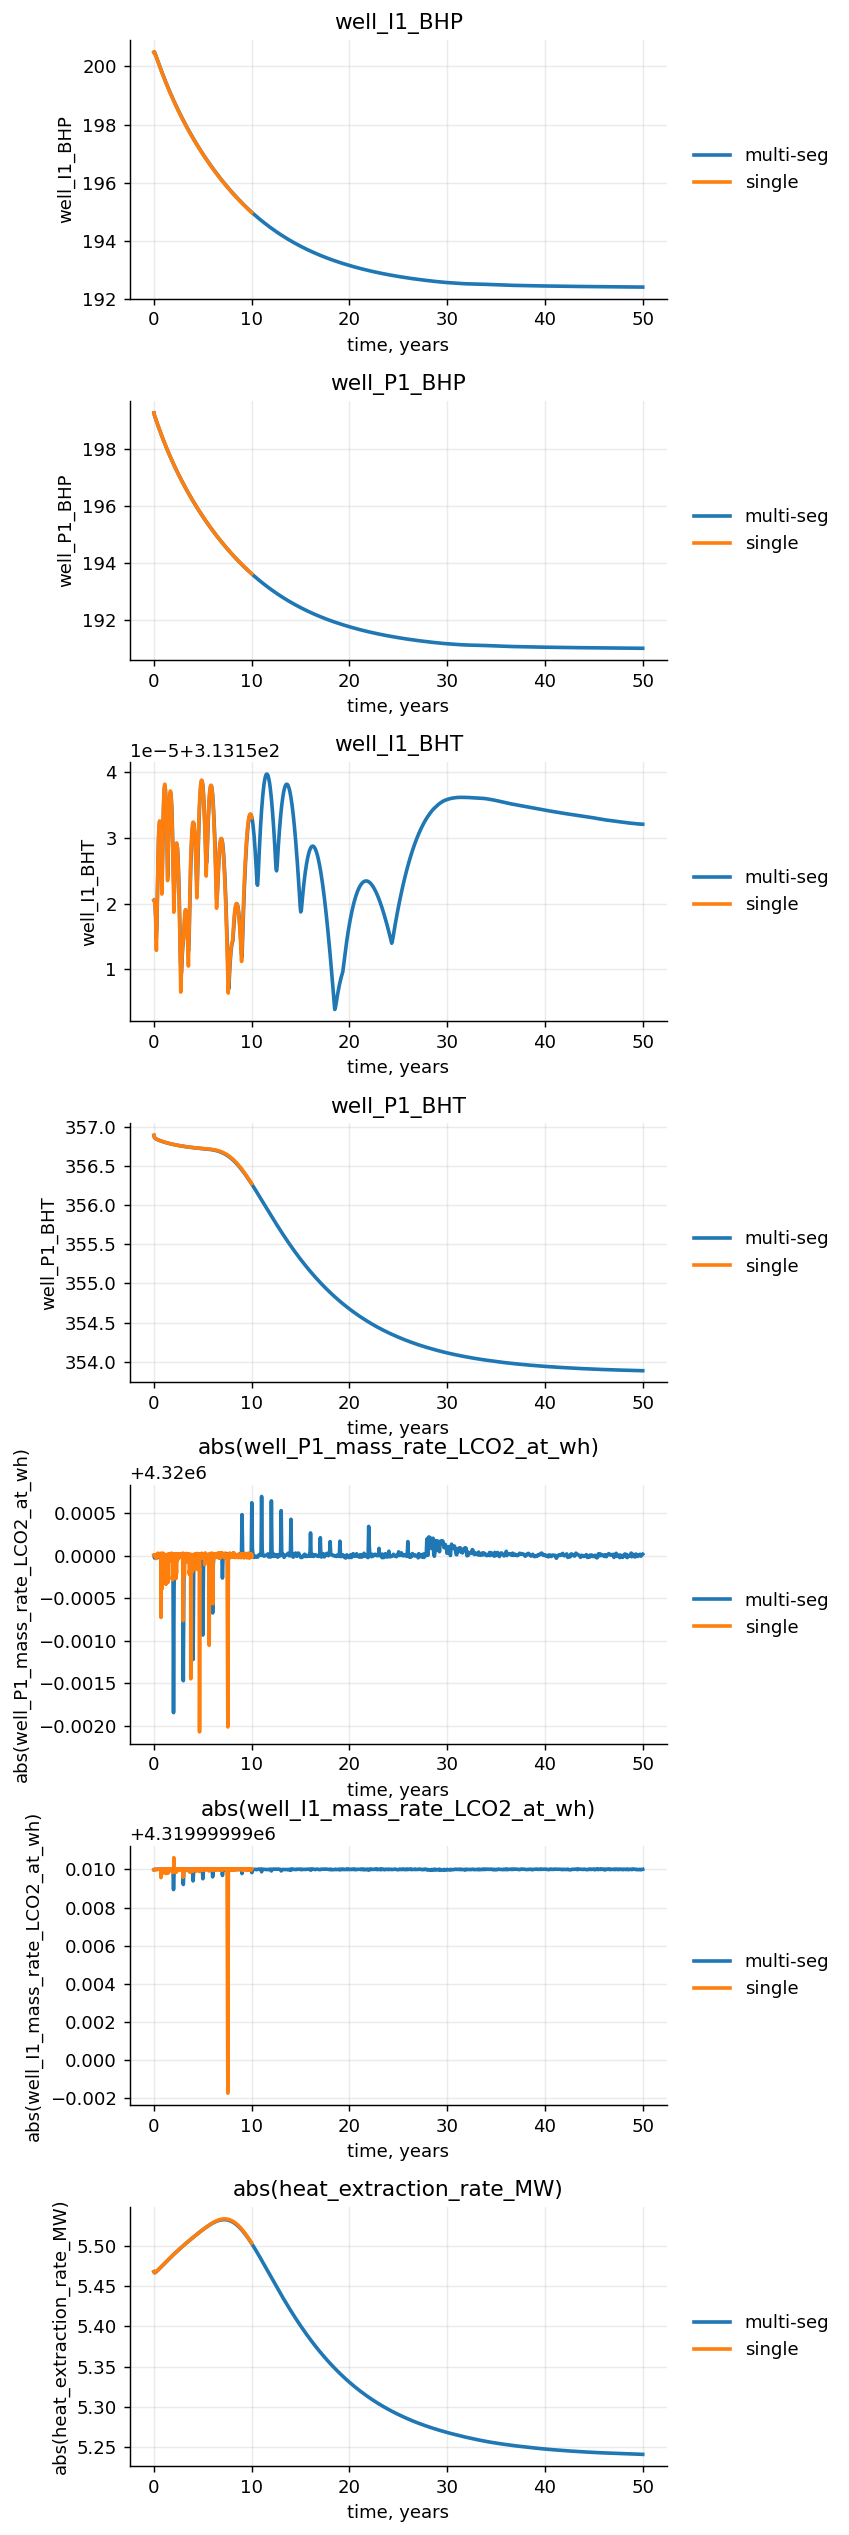

In [9]:
def plot_case_curves(cases, variables, time_scale=1.0, time_label="time"):
    n = len(variables)
    fig, axes = plt.subplots(n, 1, figsize=(8, max(3.0, 2.8 * n)), squeeze=False)
    for ax, variable in zip(axes.ravel(), variables):
        for label, case in cases.items():
            x, y = get_series(case, variable)
            xs, ys = smooth_xy(x / time_scale, y)
            ax.plot(xs, ys, linewidth=2.0, label=label)
        ax.set_title(display_variable_name(variable))
        ax.set_xlabel(time_label)
        ylabel = display_variable_name(variable)
        ax.set_ylabel(ylabel)
        ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False)
    fig.tight_layout(rect=(0, 0, 0.82, 1))
    return fig

fig = plot_case_curves(cases, VARIABLES, TIME_SCALE, TIME_LABEL)
if OUTPUT_DIR is not None:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    fig.savefig(OUTPUT_DIR / "case_variable_curves.png", bbox_inches="tight")


## Difference Against Base Case

,variable,case,base,max_abs_diff,mean_abs_diff,rmse,max_abs_rel_diff,mean_abs_rel_diff
0,well_I1_BHP,multi-seg,multi-seg,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
1,well_I1_BHP,single,multi-seg,0.015098,1.159654e-02,1.169693e-02,7.638890e-05,5.877289e-05
2,well_P1_BHP,multi-seg,multi-seg,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
3,well_P1_BHP,single,multi-seg,0.003970,1.957921e-03,2.279536e-03,1.992421e-05,9.998399e-06
4,well_I1_BHT,multi-seg,multi-seg,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
5,well_I1_BHT,single,multi-seg,0.000002,6.790621e-07,8.260986e-07,6.421208e-09,2.168488e-09
6,well_P1_BHT,multi-seg,multi-seg,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
7,well_P1_BHT,single,multi-seg,0.009349,3.771200e-03,4.890432e-03,2.621992e-05,1.057548e-05
8,well_P1_mass_rate_LCO2_at_wh,multi-seg,multi-seg,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
9,well_P1_mass_rate_LCO2_at_wh,single,multi-seg,0.002055,1.093031e-04,3.341093e-04,4.756881e-10,2.530164e-11


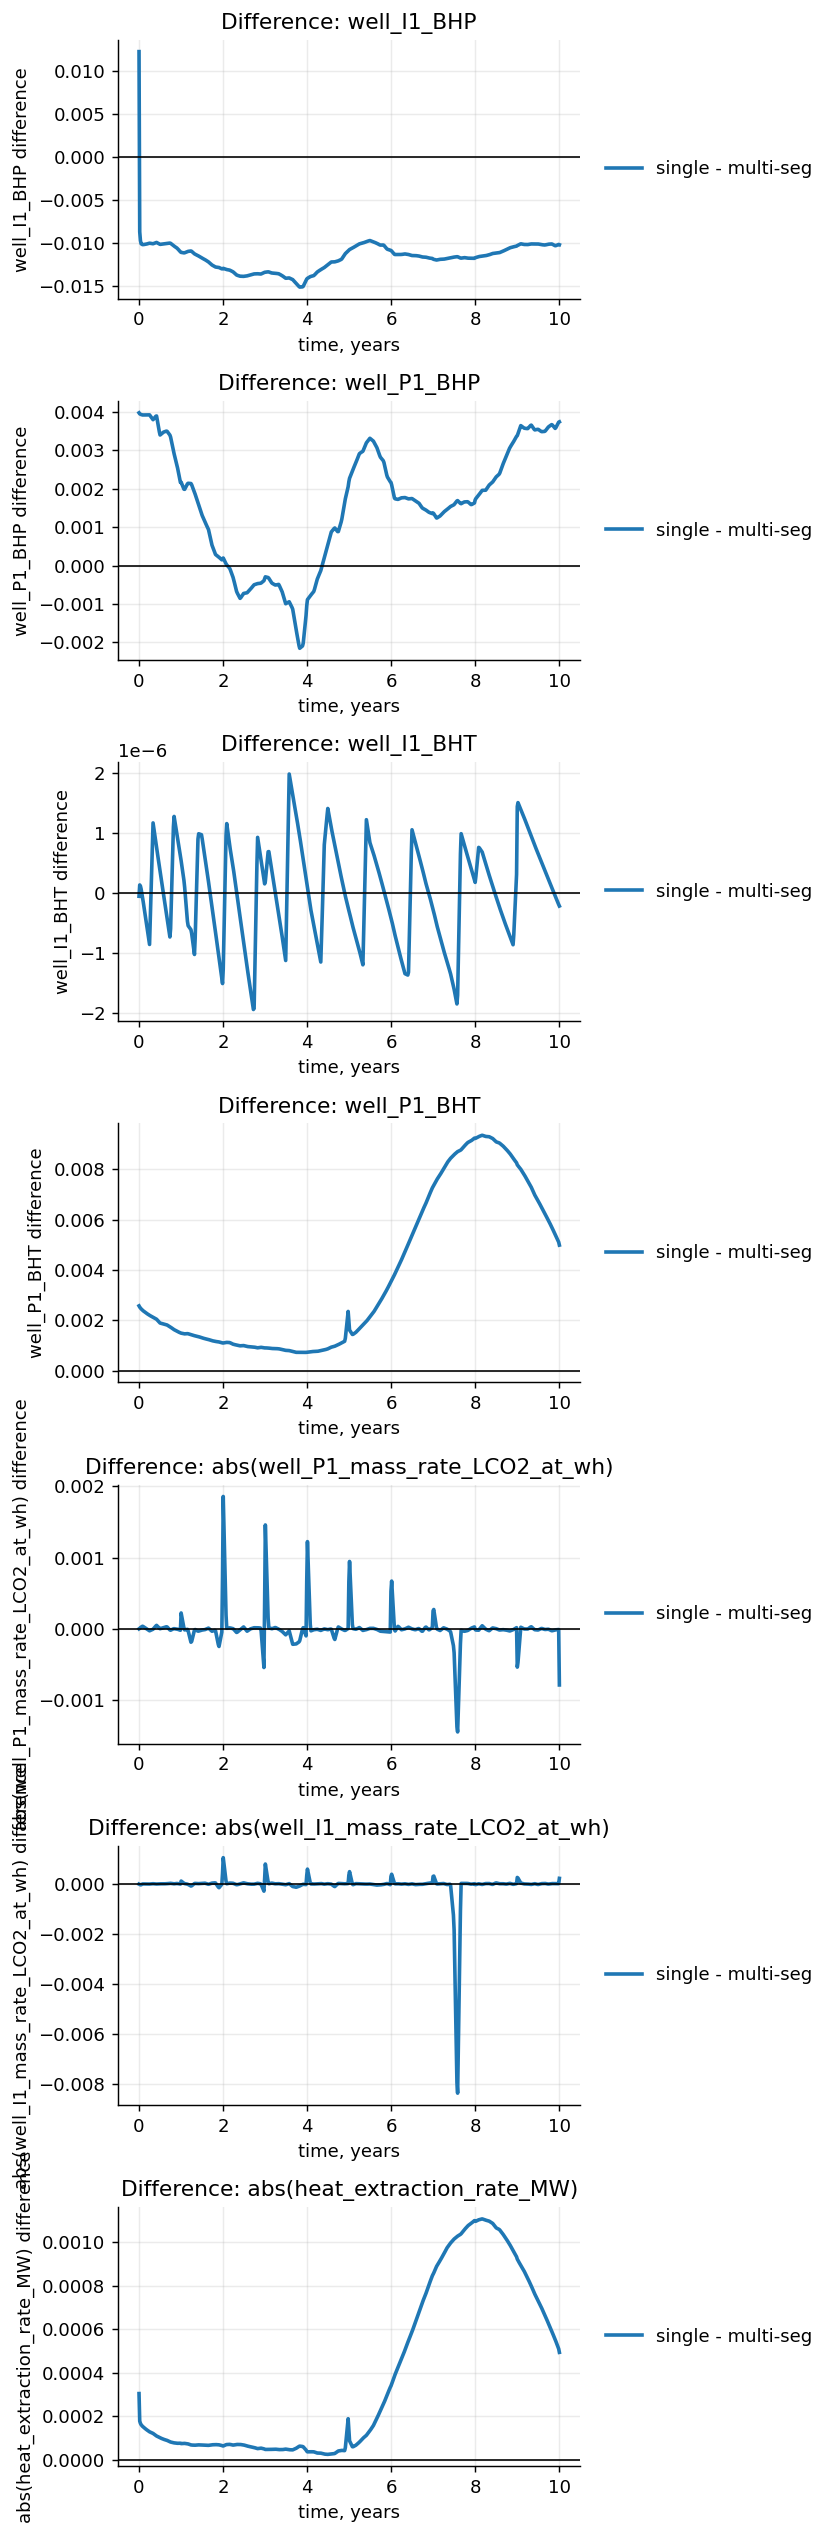

In [10]:
def plot_differences(cases, variables, base_label, time_scale=1.0, time_label="time"):
    n = len(variables)
    fig, axes = plt.subplots(n, 1, figsize=(8, max(3.0, 2.8 * n)), squeeze=False)
    stats = []
    for ax, variable in zip(axes.ravel(), variables):
        grid, aligned, summary = compare_variable(cases, variable, base_label)
        stats.append(summary)
        base = aligned[base_label]
        for label, y in aligned.items():
            if label == base_label:
                continue
            xs, ys = smooth_xy(grid / time_scale, y - base)
            ax.plot(xs, ys, linewidth=2.0, label=f"{label} - {base_label}")
        ax.axhline(0.0, color="black", linewidth=0.9)
        ax.set_title(f"Difference: {display_variable_name(variable)}")
        ax.set_xlabel(time_label)
        ylabel = f"{display_variable_name(variable)} difference"
        ax.set_ylabel(ylabel)
        ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False)
    fig.tight_layout(rect=(0, 0, 0.82, 1))
    stats_df = pd.concat(stats, ignore_index=True)
    return fig, stats_df

fig, stats_df = plot_differences(cases, VARIABLES, BASE_LABEL, TIME_SCALE, TIME_LABEL)
display(stats_df)
if OUTPUT_DIR is not None:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    fig.savefig(OUTPUT_DIR / "case_difference_curves.png", bbox_inches="tight")
    stats_df.to_excel(OUTPUT_DIR / "comparison_error_summary.xlsx", index=False)


## Overlay One Variable With Difference

如果只想详细看一个变量，修改 `VARIABLE_TO_FOCUS`。

,variable,case,base,max_abs_diff,mean_abs_diff,rmse,max_abs_rel_diff,mean_abs_rel_diff
0,heat_extraction_rate_MW,multi-seg,multi-seg,0.000000,0.000000,0.00000,0.0000,0.000000
1,heat_extraction_rate_MW,single,multi-seg,0.001106,0.000383,0.00055,0.0002,0.000069


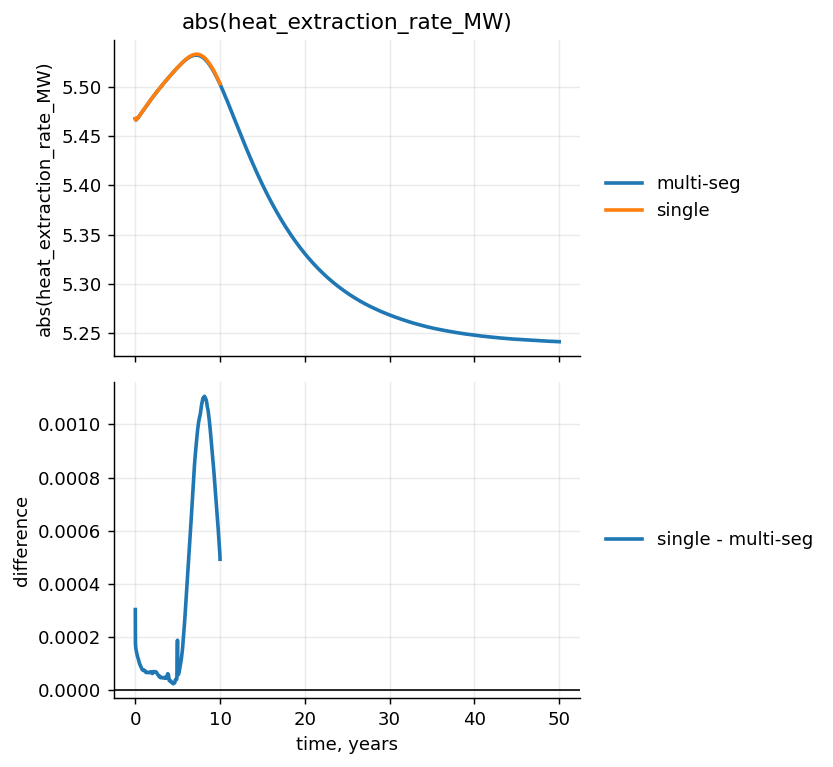

In [11]:
VARIABLE_TO_FOCUS = VARIABLES[-1]

grid, aligned, summary = compare_variable(cases, VARIABLE_TO_FOCUS, BASE_LABEL)
base = aligned[BASE_LABEL]

fig, axes = plt.subplots(2, 1, figsize=(8, 6), sharex=True)
for label, case in cases.items():
    x, y = get_series(case, VARIABLE_TO_FOCUS)
    xs, ys = smooth_xy(x / TIME_SCALE, y)
    axes[0].plot(xs, ys, linewidth=2.0, label=label)
for label, y in aligned.items():
    if label == BASE_LABEL:
        continue
    xs, ys = smooth_xy(grid / TIME_SCALE, y - base)
    axes[1].plot(xs, ys, linewidth=2.0, label=f"{label} - {BASE_LABEL}")
axes[1].axhline(0.0, color="black", linewidth=0.9)
axes[0].set_title(display_variable_name(VARIABLE_TO_FOCUS))
focus_ylabel = display_variable_name(VARIABLE_TO_FOCUS)
axes[0].set_ylabel(focus_ylabel)
axes[0].legend(loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False)
axes[1].set_xlabel(TIME_LABEL)
axes[1].set_ylabel("difference")
axes[1].legend(loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False)
fig.tight_layout(rect=(0, 0, 0.82, 1))
display(summary)
if OUTPUT_DIR is not None:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    safe_name = VARIABLE_TO_FOCUS.replace("/", "_").replace("\\", "_").replace(" ", "_")
    fig.savefig(OUTPUT_DIR / f"focus_{safe_name}.png", bbox_inches="tight")


## CO2 Injection Temperature From CoolProp

This block estimates the CO2 temperature at reservoir pressure from a known liquid-CO2 surface state. Because the initial condition can be close to the saturation boundary, the surface entropy calculation explicitly imposes the liquid branch in CoolProp. The path below is still an ideal isentropic endpoint calculation, not a full wellbore heat-transfer model.


In [8]:
# ===== CO2 injection temperature estimate =====
# Goal: liquid CO2 surface pressure + surface temperature + reservoir pressure
#       -> ideal isentropic endpoint temperature at reservoir pressure.
# This is not a full wellbore temperature model; it neglects depth, heat exchange, friction, and flow rate.
# Units: pressure in bar, temperature in K.
SURFACE_PRESSURE_BAR = 60.0
SURFACE_TEMPERATURE_K = 295.15
RESERVOIR_PRESSURE_BAR = 50.5
CO2_FLUID_NAME = "CO2"
IMPOSE_SURFACE_LIQUID_PHASE = True


def require_coolprop():
    if PropsSI is None:
        raise ImportError(
            "CoolProp is required for this block. Install it in the notebook kernel with: pip install CoolProp"
        )


def co2_phase(pressure_bar, temperature_k):
    require_coolprop()
    from CoolProp.CoolProp import PhaseSI

    return PhaseSI("P", pressure_bar * 1e5, "T", temperature_k, CO2_FLUID_NAME)


def co2_entropy_kj_per_kg_k(pressure_bar, temperature_k, impose_liquid=False):
    require_coolprop()
    pressure_key = "P|liquid" if impose_liquid else "P"
    return PropsSI("S", pressure_key, pressure_bar * 1e5, "T", temperature_k, CO2_FLUID_NAME) / 1000.0


def co2_temperature_from_entropy_and_pressure_k(entropy_kj_per_kg_k, pressure_bar):
    require_coolprop()
    return PropsSI("T", "P", pressure_bar * 1e5, "S", entropy_kj_per_kg_k * 1000.0, CO2_FLUID_NAME)


def reservoir_temperature_from_liquid_surface_condition(
    surface_pressure_bar,
    surface_temperature_k,
    reservoir_pressure_bar,
):
    surface_entropy_kj_per_kg_k = co2_entropy_kj_per_kg_k(
        surface_pressure_bar,
        surface_temperature_k,
        impose_liquid=IMPOSE_SURFACE_LIQUID_PHASE,
    )
    reservoir_temperature_k = co2_temperature_from_entropy_and_pressure_k(
        surface_entropy_kj_per_kg_k,
        reservoir_pressure_bar,
    )
    return reservoir_temperature_k, surface_entropy_kj_per_kg_k


critical_pressure_bar = PropsSI("Pcrit", CO2_FLUID_NAME) / 1e5
critical_temperature_k = PropsSI("Tcrit", CO2_FLUID_NAME)
reservoir_temperature_k, surface_entropy_kj_per_kg_k = reservoir_temperature_from_liquid_surface_condition(
    SURFACE_PRESSURE_BAR,
    SURFACE_TEMPERATURE_K,
    RESERVOIR_PRESSURE_BAR,
)

surface_phase = co2_phase(SURFACE_PRESSURE_BAR, SURFACE_TEMPERATURE_K)
reservoir_phase = co2_phase(RESERVOIR_PRESSURE_BAR, reservoir_temperature_k)

print("Assumption: ideal isentropic path from liquid-CO2 surface condition to reservoir pressure")
print("Interpretation: reversible adiabatic endpoint, not a full wellbore temperature prediction")
print(f"CO2 critical point: Pcrit={critical_pressure_bar:.3f} bar, Tcrit={critical_temperature_k:.2f} K ({critical_temperature_k - 273.15:.2f} degC)")
print(f"Surface condition: P={SURFACE_PRESSURE_BAR:.3f} bar, T={SURFACE_TEMPERATURE_K:.2f} K ({SURFACE_TEMPERATURE_K - 273.15:.2f} degC)")
print(f"Surface phase from CoolProp: {surface_phase}")
print(f"Surface entropy branch: {'liquid imposed' if IMPOSE_SURFACE_LIQUID_PHASE else 'automatic'}")
print(f"Conserved entropy: s={surface_entropy_kj_per_kg_k:.6f} kJ/kg/K")
print(f"Reservoir pressure: P={RESERVOIR_PRESSURE_BAR:.3f} bar")
print(
    "Estimated CO2 temperature at reservoir pressure: "
    f"{reservoir_temperature_k:.2f} K ({reservoir_temperature_k - 273.15:.2f} degC)"
)
print(f"Reservoir-pressure endpoint phase from CoolProp: {reservoir_phase}")


Assumption: ideal isentropic path from liquid-CO2 surface condition to reservoir pressure
Interpretation: reversible adiabatic endpoint, not a full wellbore temperature prediction
CO2 critical point: Pcrit=73.773 bar, Tcrit=304.13 K (30.98 degC)
Surface condition: P=60.000 bar, T=295.15 K (22.00 degC)
Surface phase from CoolProp: gas
Surface entropy branch: liquid imposed
Conserved entropy: s=1.210608 kJ/kg/K
Reservoir pressure: P=50.500 bar
Estimated CO2 temperature at reservoir pressure: 287.85 K (14.70 degC)
Reservoir-pressure endpoint phase from CoolProp: unknown: Saturation pressure [5.05e+06 Pa] corresponding to T [287.846 K] is within 1e-4 % of given p [5.05e+06 Pa] : PropsSI("Phase","P",5050000,"T",287.8459286,"CO2")
